# Cài đặt các Thư viện sử dụng

In [5]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier

# Cài đặt hiển thị dataFrame

In [6]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Đọc dữ liệu


- vn_news_223_tdlfr.csv là file chứa news cần xử lý
- vietnamese-stopwords.txt chứa các stop word cần xử lý

In [7]:
data_df = pd.read_csv("data_train.csv", encoding = 'utf-8')
with open('vietnamese-stopwords.txt', 'r', encoding='utf-8') as file:
    stopWords = file.read().split('\n')

# Khám phá dữ liệu

## Mẫu dữ liệu

In [8]:
data_df.sample(5)

title  \
1199                                                   Tiếp nối lý tưởng cách mạng của cha anh   
94    Liên tục được con trai báo mộng, bà mẹ kinh hãi khi nhìn thấy cảnh tượng khi thăm mộ con   
1335     Huấn luyện kỹ năng nghiệp vụ phòng cháy, chữa cháy cho các hộ kinh doanh trên địa bàn   
1105                Lần đầu tiên trong nhiệm kỳ, Thường vụ Quốc hội chất vấn để 'giám sát lại'   
337                                                     Nhiều chuyến bay còn trống chỗ dịp 2/9   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

## Xem thông tin

In [9]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          1395 non-null   object
 1   text           1395 non-null   object
 2   author         1234 non-null   object
 3   source_domain  1395 non-null   object
 4   label          1395 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 54.6+ KB


## Xem mô tả

In [10]:
data_df.describe().round(1)

,label
count,1395.0
mean,0.2
std,0.4
min,0.0
25%,0.0
50%,0.0
75%,0.0
max,1.0


## Xem số dòng và số cột của dữ liệu

In [11]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

1395
5


## ý nghĩa của các dòng

### Kiểm tra dữ liệu có bị lặp ?

In [12]:
dup=data_df.index.duplicated().sum()
dup

0

### ý nghĩa các cột

- text: nội dung của tin tức
- domain: đường dẫn đến trang web chứa tin tức 
- label: nhãn phân biệt tin giả hay tin thật

### Dữ liệu có bị thiếu không?

In [13]:
data_df['title'].isnull().sum()

0

In [14]:
data_df['text'].isnull().sum()

0

In [15]:
data_df['author'].isnull().sum()

161

In [16]:
data_df['source_domain'].isnull().sum()

0

In [17]:
data_df['label'].isnull().sum()

0

### Mỗi cột hiện đang có kiểu dữ liệu gì? Có cột nào có kiểu dữ liệu chưa phù hợp để có thể xử lý tiếp không?

In [18]:
data_df.dtypes

title            object
text             object
author           object
source_domain    object
label             int64
dtype: object

#### Cột có dtype là object nghĩa là sao?

- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [19]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [20]:
open_object_dtype(data_df['title'])

{str}

In [21]:
open_object_dtype(data_df['text'])

{str}

In [22]:
open_object_dtype(data_df['author'])

{float, str}

In [23]:
open_object_dtype(data_df['source_domain'])

{str}

In [24]:
open_object_dtype(data_df['label'])

{int}

#### Kiểm tra phân bố các class có chênh lệch không?

label
0    83.225806
1    16.774194
Name: proportion, dtype: float64

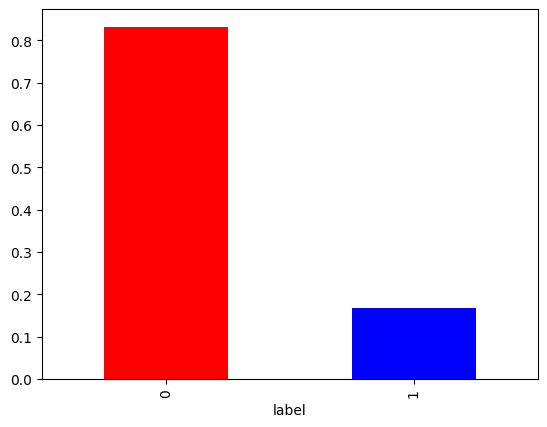

In [25]:
data_df.label.value_counts(normalize=True).plot(kind="bar", 
                                                color=["red", "blue"])
data_df['label'].value_counts(normalize=True) * 100

#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [26]:
len_sum=0
for i in data_df['text']:
    len_sum+=len(i)
len_avg=len_sum/data_df['text'].count()
len_avg

2892.689605734767

##### Record dài nhất là bao nhiêu?

In [27]:
max_len=0
for i in data_df['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

33691

##### Record ngắn nhất là bao nhiêu?

In [28]:
min_len=len(data_df['text'][0])
for i in data_df['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

10

##### Tin tức được thu thập từ trang web nào nhiều nhất?

In [29]:
data_df['source_domain'].value_counts()

source_domain
vnexpress.net             586
dantri.com.vn             171
vietnamnet.vn             140
baomoi.com                118
viettan.org               103
thanhnien.vn               80
tinvn.info                 68
nhandan.vn                 45
tuoitre.vn                 21
thoibao.today               6
tintucqpvn.net              5
www.webtretho.com           4
anninh247.xyz               4
phapluat.news               3
baophapluat.online          3
giadinhtiepthi.com          2
thoibao.de                  2
congtintuc24gio.com         2
www.ipick.vn                2
thegioitre.vn               2
danviet.vn                  2
soha.vn                     1
kenh14.vn                   1
trumpandq.blogspot.com      1
lichngaytot.com             1
tuvanannam.com              1
blogxcy.wordpress.com       1
shopjaxvinhphuc.vn          1
tintuconline.com.vn         1
2sao.vn                     1
nuochoauk.vn                1
sorry.vn                    1
www.gioitreviet.net       

### Tiền xử lí văn bản tiếng việt

#### Loại bỏ các đường link và các dấu câu, lowercase

In [30]:
def wordopt(text):
    text = text.lower()
    text = re.sub('https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('[^\w\s]',' ',text) 
    text = re.sub('\n', ' ', text)
    return text

In [31]:
data_df["text"]=data_df["text"].apply(wordopt)

In [32]:
data_df.head()

,title,text,author,source_domain,label
0,"Con gái chính là người tình kiếp trước của cha . Cách yêu thương của cha dành cho con gái thật vô cùng đặc biệt và ấm áp...Câu nói ""con gái là người tình kiếp trước của cha"" để chỉ mối quan hệ thân thiết, gắn bó giữa cha và con....So với mẹ, cha thường ít thể hiện tình cảm hơn, đặc biệt là khi đã lớn nên chúng ta luôn có cảm giác xa cách....Thế nhưng, dù không nói ra thì cha vĩnh viễn là người đàn ông bao dung, yêu thương và mang đến cho bạn những điều tốt đẹp nhất....Sự kết nối giữa cha và con gái là thứ tình cảm không thể phá vỡ....Cái được gọi là “yêu từ cái nhìn đầu tiên” của cha dành cho con luôn vĩnh viễn....Con là một công chúa, không phải vì con có một hoàng tử mà bởi cha con là 1 vị vua....Trên mỗi bước chân con đi đều có cha dõi theo....Cha sẽ bảo vệ con khỏi những tổn thương và bất hạnh bằng tất cả sức lực của mình....Có thể cha chưa đủ khéo, nhưng sẵn sàng làm tất cả cho con từ những việc nhỏ nhặt nhất....Cha vừa là vệ sĩ vừa là người bạn trung thành....Mọi khoảnh khắc bên cha đều thật dễ thương..",thế nhưng dù không nói ra thì cha vĩnh viễn là người đàn ông bao dung yêu thương và mang đến cho bạn những điều tốt đẹp nhất,NaN,2sao.vn,1
1,Thủ tướng Abe cúi đầu xin lỗi vì hành động phi thể thao của tuyển Nhật,theo sankei sports sáng nay thủ tướng nhật bản shinzo abe công khai gửi lời xin lỗi tới nhật hoàng và toàn bộ người dân vì tinh thần thi đấu phi thể thao của đội tuyển nhật tại world cup 2018 tối qua sau lượt trận cuối vòng bảng world cup 2018 nhật bản có cùng chỉ số phụ như senegal đội bị loại sau khi thua colombia nhưng nhật bản vào vòng sau nhờ chỉ số fair play vì nhận ít thẻ phạt hơn thủ tướng nhật bản shinzo abe cúi đầu xin lỗi với tinh thần của những võ sĩ đạo samurai nhưng đội tuyển nhật bản đã có những hành động thiếu tinh thần thượng võ trong thi đấu tại world cup để lại nhiều chỉ trích và bất bình cho toàn dân làm mất hình ảnh kiên cường của người dân nhật bản trên đấu trường quốc tế là người đứng đầu tôi xin thành thật nhận trách nhiệm và gửi lời xin lỗi sâu sắc tới nhân dân ông abe cúi đầu nhận trách nhiệm về mình người nhật bản nổi tiếng về tinh thần trách nhiệm và chất võ sĩ đạo đó là lý do đội tuyển áo xanh được mệnh danh samurai xanh tuy nhiên nhật bản sau đó nhận chỉ trích dữ dội của người hâm mộ bóng đá vì lối chơi bóng tiêu cực cố tình câu giờ để dành tấm vé đi tiếp cụ thể những phút cuối trận cuối vòng bảng gặp ba lan do biết ở trận cùng giờ colombia cũng đang thắng senegal với tỷ số 1 0 nên dù có đang bị dẫn trước với tỉ số tương tự các cầu thủ nhật bản cũng không hề muốn gỡ hòa các cầu thủ nhật vui vẻ sau trận thua ba lan 0 1 có vé vào vòng 16 đội tại world cup 2018 fifa sẽ tính điểm fair play theo quy định 1 thẻ vàng 1 điểm 2 thẻ vàng thành thẻ đỏ 3 điểm thẻ đỏ trực tiếp 4 điểm nhật có 4 thẻ vàng còn senegal có đến 6 chính vì sợ lãnh thêm thẻ vàng nên nhật đã giết chết trận đấu trong những phút cuối họ liên tục chuyền bóng qua lại ở phần sân nhà thậm chí trong khoảng 5 phút cuối cầu thủ nhật bản còn không đưa bóng sang phần sân đối phương bất chấp sự la ó huýt sáo của các cđv trên sân điều này khiến thầy trò hlv akira nishino bị dư luận chỉ trích với kết quả trên nhật bản và colombia là hai đội đi tiếp của bảng h ở vòng loại trực tiếp nhật bản sẽ phải đối đầu với đối thủ cực mạnh là đt bỉ trong khi đó đội cùng đi tiếp với nhật là colombia sẽ gặp đt anh,Văn Trình,binhluan.biz,1
2,Thủ tướng Nhật cúi đầu xin lỗi vì tinh thần phi thể thao của đội bóng,sáng 19 6 thủ tướng nhật bản shinzo abe công khai gửi lời xin lỗi tới nhật hoàng và toàn bộ người dân vì tinh thần thi đấu phi thể thao của đội tuyển nhật tại world cup 2018 với tinh thần của những võ sĩ đạo samurai nhưng đội tuyển nhật bản đã có những hành động thiếu tinh thần thượng võ trong thi đấu tại world cup để lại nhiều chỉ trích và bất bình cho toàn dân làm mất hình ảnh kiên cường của người dân nhật bản trên đấu trường quốc tế là người đứng đầu tôi xin thành thật nhận trách nhiệm và gửi lời xin 

#### Tokenizer

In [33]:
def tokenize(sentence):
    return word_tokenize(sentence, format = 'word')

### Mô hình hóa

- Chuyển đoạn văn tiếng Việt về vector, sử dụng CountVectorizer của sklearn
- với các tham số là danh sách stopwords tiếng Việt
- và tokenizer tách từ tiếng Việt

In [34]:
vectorizer = CountVectorizer(
    stop_words = stopWords,
    tokenizer = tokenize,
    token_pattern=None    # Bỏ qua tham số token_pattern
)

Chia tập dữ liệu thành 2 tập

- Tập train: 75%
- Tập test: 25%


In [35]:
X = data_df["text"]
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)
Xv_train = vectorizer.fit_transform(X_train)
Xv_test = vectorizer.transform(X_test)

c:\Users\ASUS\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\feature_extraction\text.py:406: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['a', 'bao', 'bay', 'biến', 'bây', 'bất', 'bất thình', 'bất ý', 'bập', 'bội', 'chao', 'chi', 'chui', 'chà', 'chành', 'chí', 'chót', 'chùn', 'chăn', 'chũn', 'chưng', 'chạnh', 'chả', 'chầm', 'chập', 'chắn', 'chẳng', 'chết', 'chốc', 'chừ', 'chừng', 'chừng nào', 'coi', 'cu', 'câu', 'cóc', 'cạnh', 'cật', 'cắt', 'cổ', 'cục', 'cực', 'da', 'dà', 'dĩ', 'dần', 'dầu', 'dở', 'giời', 'ha', 'hèn', 'hô', 'hầu', 'hậu', 'hẳn', 'hồ', 'hự', 'khói', 'khô', 'kê', 'kìa', 'lai', 'le', 'loạt', 'luật', 'luốt', 'lình', 'lí', 'lô', 'lý', 'lẽ', 'lị', 'lự', 'lực', 'mày', 'mòi', 'mù', 'mạng', 'mấy', 'mẹ', 'mực', 'ngõ', 'ngăn', 'ngắt', 'ngộ', 'nhiên', 'nhung', 'nhén', 'nhón', 'nhăng', 'nhược', 'nhỡ', 'nả', 'nỗi', 'nở', 'nức', 'oai', 'phi', 'phui', 'phăn', 'phương', 'phỉ', 'quy', 'quy lại', '

In [36]:
joblib.dump(vectorizer, 'vectorizer.joblib')

['vectorizer.joblib']

### Decision Tree

In [37]:
DT = DecisionTreeClassifier()
DT.fit(Xv_train,y_train)

DecisionTreeClassifier()

In [38]:
pred_dt = DT.predict(Xv_test)
print(DT.score(Xv_test, y_test))
#save model Decision Tree
joblib.dump(DT, 'DT_model.joblib')

0.9169054441260746


['DT_model.joblib']

### Naive Bayes

In [39]:
NB = MultinomialNB()
NB.fit(Xv_train,y_train)

MultinomialNB()

In [40]:
pred_nb = DT.predict(Xv_test)
print(NB.score(Xv_test, y_test))
#save model Naive Bayes
joblib.dump(NB, 'NB_model.joblib')

0.9340974212034384


['NB_model.joblib']

### Đánh giá mô hình

- Mô hình với Decesion Tree  có độ chính xác cao khoảng 95%
- Mô hình với Naive Bayes có độ chính xác cao khoảng 95%